# Projekat: Segmentacija E-Commerce Kupaca i Narudzbina 

**Tema**: Nenadgledano ucenje - Klasterizacija

**Dataset**: [E-Commerce Sales Dataset (Amazon Sale Report)](https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data)


## Definicija problema i ucitavanje podataka

### Cilj: Primenom algoritama nenadgledanog ucenja izvrsiti segmentaciju Amazon e-commerce narudzbina na osnovu njihovih karakteristika: **iznosa**, **kolicine**, **kategorije** **proizvoda** i **tipa kupca** (**B2B/B2C**).

### **Krajnji cilj** je otkriti prirodne grupe narudzbina koje mogu pomoci u boljem razumevanju kupackih obrazaca na Amazon India platformi.

### Ucitavanje biblioteka i skupa podataka.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

import warnings
warnings.filterwarnings("ignore")

In [52]:
df = pd.read_csv('data/amazon_sale_report.csv')

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## Deskriptivna analiza i priprema podataka

### Istrazivanje dataseta

In [53]:
print(f"Shape: {df.shape}")
print(f"\nKolone:\n{df.columns.tolist()}")
print(f"\nTipovi podataka:\n{df.dtypes}")
print(f"\nMissing vrednosti:\n{df.isnull().sum()}")
print(f"\nStatistike:\n{df.describe()}")

Shape: (128975, 24)

Kolone:
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']

Tipovi podataka:
index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
ship-state                str
ship-postal-code      float64
ship-country              str
promotion-ids             str
B2B                 

In [54]:
df = df.drop(columns=[
    'Unnamed: 22',
    'fulfilled-by',
    'Order ID',
    'promotion-ids',
    'ASIN',
    'SKU',
    'index',
    'ship-country',
    'ship-postal-code',
    'currency'
])

df.shape

(128975, 14)

In [55]:
print(f'Duplikati: ', df.duplicated().sum())

df = df.drop_duplicates()

print(f'Duplikati: ', df.duplicated().sum())

df.shape

Duplikati:  2442
Duplikati:  0


(126533, 14)

In [60]:
df = df[df['Amount'] > 0]
df = df[df['Qty'] > 0]
df = df.dropna(subset=['Amount', 'Qty'])

df['Courier Status'] = df['Courier Status'].fillna('Unknown')
df['ship-city'] = df['ship-city'].fillna('Unknown')
df['ship-state'] = df['ship-state'].fillna('Unknown')

print(f'Shape nakon ciscenja: {df.shape}')
print(f'\nPreostale NaN vrednosti:\n{df.isnull().sum()}')

Shape nakon ciscenja: (111878, 14)

Preostale NaN vrednosti:
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
Category              0
Size                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
B2B                   0
dtype: int64


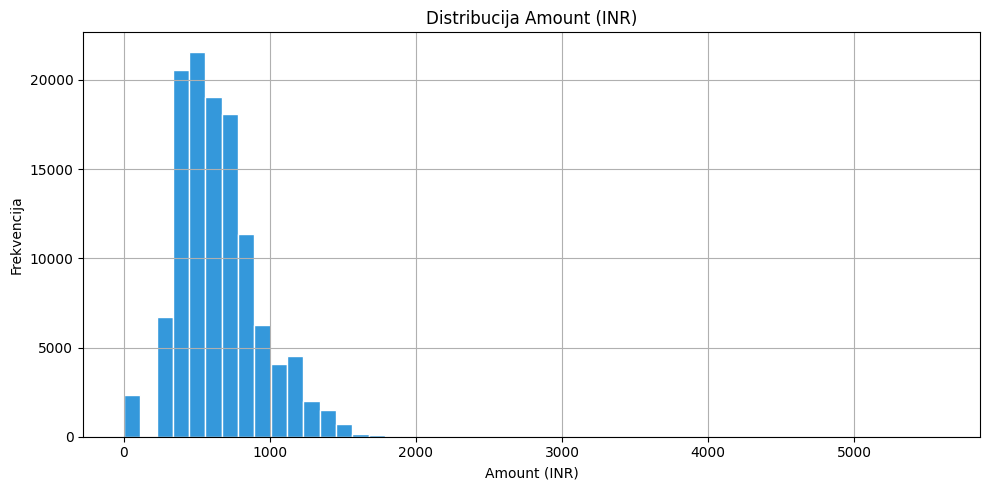

In [56]:
plt.figure(figsize=(10, 5))

df['Amount'].dropna().hist(bins=50, color='#3498db', edgecolor='white')

plt.title('Distribucija Amount (INR)')
plt.xlabel('Amount (INR)')
plt.ylabel('Frekvencija')
plt.tight_layout()
plt.show()

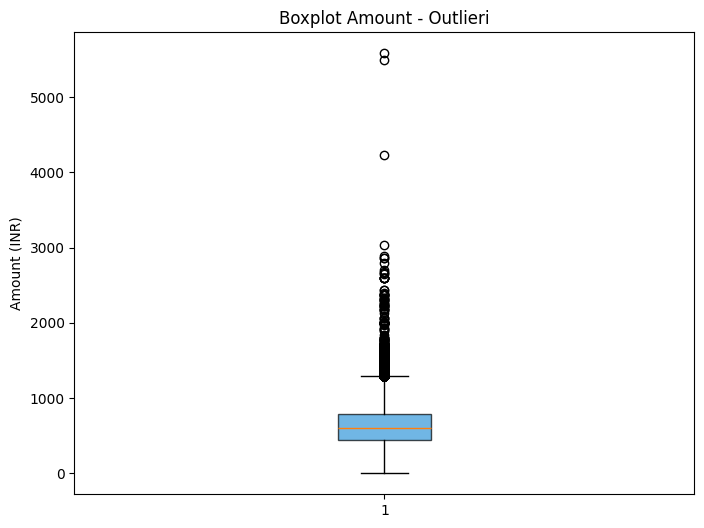

In [57]:
plt.figure(figsize=(8, 6))
plt.boxplot(df['Amount'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.7))
plt.title('Boxplot Amount - Outlieri')
plt.ylabel('Amount (INR)')
plt.show()

In [58]:
print(df[df['Amount'] == 0]['Status'].value_counts())
print(df[df['Qty'] == 0]['Status'].value_counts())

Status
Shipped                          1517
Shipped - Delivered to Buyer      716
Shipped - Returned to Seller       51
Shipped - Picked Up                28
Pending                            17
Pending - Waiting for Pick Up       9
Shipped - Lost in Transit           2
Shipped - Returning to Seller       2
Name: count, dtype: int64
Status
Cancelled                       12084
Shipped                            93
Shipped - Delivered to Buyer        8
Shipped - Returned to Seller        3
Pending                             2
Name: count, dtype: int64


In [59]:
df['Date'] = pd.to_datetime(df['Date'])